In [6]:
import pandas as pd
import numpy as nm
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
data = pd.read_excel(
    "online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

In [8]:
data = data.dropna()


In [9]:
print(data.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


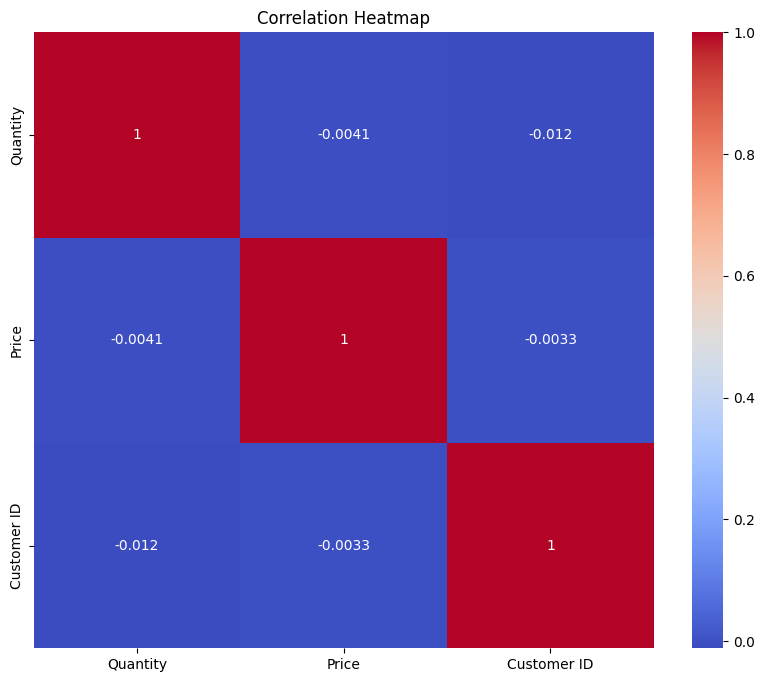

In [10]:
numeric_data = data.select_dtypes(include=['number'])

corr = numeric_data.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [11]:

print(data.describe())

            Quantity                    InvoiceDate          Price  \
count  417534.000000                         417534  417534.000000   
mean       12.758815  2010-07-01 01:12:19.787609856       3.887547   
min     -9360.000000            2009-12-01 07:45:00       0.000000   
25%         2.000000            2010-03-26 11:26:00       1.250000   
50%         4.000000            2010-07-08 19:12:00       1.950000   
75%        12.000000            2010-10-14 14:08:00       3.750000   
max     19152.000000            2010-12-09 20:01:00   25111.090000   
std       101.220424                            NaN      71.131797   

         Customer ID  
count  417534.000000  
mean    15360.645478  
min     12346.000000  
25%     13983.000000  
50%     15311.000000  
75%     16799.000000  
max     18287.000000  
std      1680.811316  


In [12]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 417534 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      417534 non-null  object        
 1   StockCode    417534 non-null  object        
 2   Description  417534 non-null  object        
 3   Quantity     417534 non-null  int64         
 4   InvoiceDate  417534 non-null  datetime64[ns]
 5   Price        417534 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      417534 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 28.7+ MB
None


In [13]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [14]:
data['TotalPrice'] = data['Quantity'] * data['Price']

In [15]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [16]:
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

In [17]:
rfm = data.groupby('Customer ID').agg({

    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,

    'Invoice': 'nunique',

    'TotalPrice': 'sum'

})

In [18]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [19]:
print(rfm.head())


             Recency  Frequency  Monetary
Customer ID                              
12346.0           67         15    -64.68
12347.0            3          2   1323.32
12348.0           74          1    222.16
12349.0           43          4   2646.99
12351.0           11          1    300.93


In [20]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [21]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [22]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [23]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [24]:
def segment_customer(score):

    if score == '444':
        return 'Champion'

    elif score[0] == '4':
        return 'Loyal Customer'

    elif score[0] == '1':
        return 'At Risk'

    else:
        return 'Regular'


rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

In [25]:
print(rfm['Segment'].value_counts())


Segment
Regular           2195
At Risk           1089
Loyal Customer     630
Champion           469
Name: count, dtype: int64


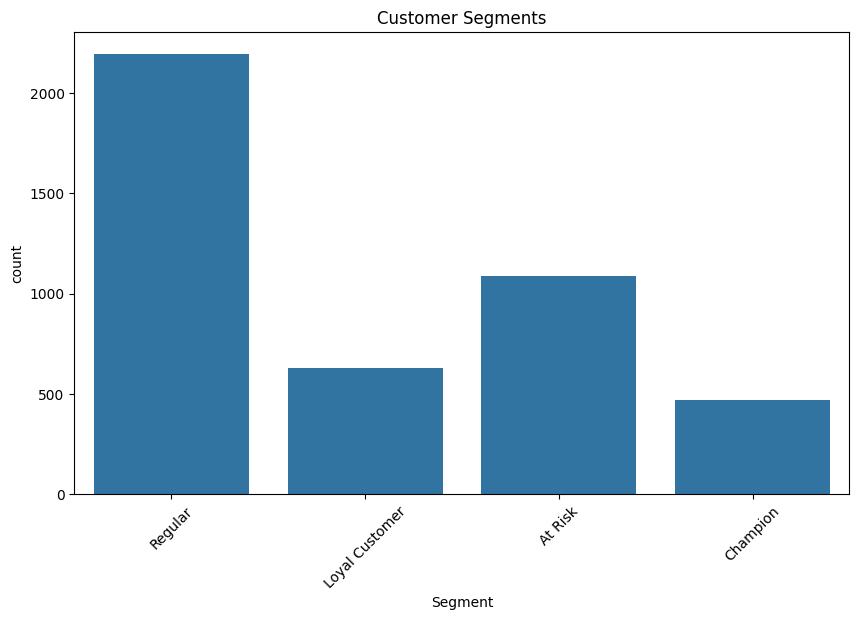

In [26]:
plt.figure(figsize=(10,6))

sns.countplot(x='Segment', data=rfm)

plt.xticks(rotation=45)

plt.title("Customer Segments")

plt.show()

In [27]:
top_customers = rfm.sort_values(
    by='Monetary',
    ascending=False
)

print(top_customers.head(10))

             Recency  Frequency   Monetary R_Score F_Score M_Score RFM_Score  \
Customer ID                                                                    
18102.0            1         95  341776.73       4       4       4       444   
14646.0           10         87  243853.05       4       4       4       444   
14156.0            7        138  183180.55       4       4       4       444   
14911.0            1        270  137675.91       4       4       4       444   
13694.0            9        105  128172.42       4       4       4       444   
17511.0            3         42   83760.60       4       4       4       444   
15061.0            3         90   82162.74       4       4       4       444   
16684.0           15         34   75610.17       4       4       4       444   
13089.0            4        132   55828.31       4       4       4       444   
16754.0            8         35   54558.18       4       4       4       444   

              Segment  
Customer ID    

In [28]:
data['InvoiceMonth'] = data['InvoiceDate'].dt.to_period('M')

cohort = data.groupby('Customer ID')['InvoiceMonth'].min()
data['CohortMonth'] = data['Customer ID'].map(cohort)

cohort_data = data.groupby(['CohortMonth', 'InvoiceMonth'])['Customer ID'] \
    .nunique() \
    .reset_index()

In [29]:
max_date = data['InvoiceDate'].max()

customer_last_purchase = data.groupby('Customer ID')['InvoiceDate'].max()

churn_days = (max_date - customer_last_purchase).dt.days

churn = (churn_days > 90).astype(int)

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [32]:
monetary = data.groupby('Customer ID')['TotalPrice'].sum()

# Frequency: number of purchases (unique invoices)
frequency = data.groupby('Customer ID')['Invoice'].nunique()

# Recency: days since last purchase
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)
recency = data.groupby('Customer ID')['InvoiceDate'].max().apply(lambda x: (snapshot_date - x).days)

# Tenure: days since first purchase
tenure = data.groupby('Customer ID')['InvoiceDate'].min().apply(lambda x: (snapshot_date - x).days)

# CategoryCount: number of unique product categories purchased
category_count = data.groupby('Customer ID')['StockCode'].nunique()

# Combine into feature table
data = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary,
    'Tenure': tenure,
    'CategoryCount': category_count
})

# Define churn label (example: no purchase in last 90 days)
data['Churn'] = (data['Recency'] > 90).astype(int)

In [33]:
data.head()

,Recency,Frequency,Monetary,Tenure,CategoryCount,Churn
Customer ID,,,,,,
12346.0,67,15,-64.68,361,29,0
12347.0,3,2,1323.32,40,70,0
12348.0,74,1,222.16,74,20,0
12349.0,43,4,2646.99,371,92,0
12351.0,11,1,300.93,11,21,0


In [34]:
from sklearn.metrics import classification_report, roc_auc_score

In [35]:
X = data[['Recency','Frequency','Monetary','Tenure','CategoryCount']]
y = data['Churn']  # 1 = churned, 0 = active

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       896
           1       1.00      1.00      1.00       419

    accuracy                           1.00      1315
   macro avg       1.00      1.00      1.00      1315
weighted avg       1.00      1.00      1.00      1315

ROC-AUC: 1.0


In [36]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import joblib
joblib.dump(model,'churn_model.pkl')

['churn_model.pkl']

In [38]:
pip install streamlit

   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ------------ --------------------------- 2.9/9.2 MB 14.4 MB/s eta 0:00:01
   ------------------------- -------------- 5.8/9.2 MB 13.8 MB/s eta 0:00:01
   ------------------------------------- -- 8.7/9.2 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 13.2 MB/s  0:00:00
   ---------------------------------------- 0.0/797.0 kB ? eta -:--:--
   ---------------------------------------- 797.0/797.0 kB 7.3 MB/s  0:00:00
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.9/11.3 MB 13.4 MB/s eta 0:00:01
   ------------------- -------------------- 5.5/11.3 MB 13.4 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.3 MB 13.3 MB/s eta 0:00:01
   -------------------------------------- - 11.0/11.3 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 12.9 MB/s  0:00:00
   ----------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
